# Environment validation
The first cell automatically selects the repository root.

In [1]:
# Make imports work whether VS Code starts in the repository or notebooks folder.
import os
import sys
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError(f"Cannot find the project root from {Path.cwd()}")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("Project root:", ROOT)

Project root: c:\Users\jahav\OneDrive\janudrive\project\EV-Charging-RL-Optimizer


In [2]:
from src.environment.ev_charging_env import EVChargingEnv
from src.rl.common import validate_environment
env=EVChargingEnv(debug=True); validate_environment(env)

STEP 1
EV SOC: 45.4%  Required Energy: 31.5 kWh  Safe Range: 151.5 km
ENVIRONMENT Weather severity: 0.73  Traffic: 0.43  Hour: 4
ACTION Recommended index: 7  Actual index: 7
RESULT Travel: 21.2  Wait: 0.0  Charge: 98.7  Cost: 805.2
REWARD 87.72 {'waiting': 100.0, 'travel': 82.29803415402147, 'cost': 66.64568269373972, 'utilization': 100.0, 'balance': 87.52780871075353, 'demand': 75.05994303691512, 'compatibility': 100.0}
STEP 1
EV SOC: 45.4%  Required Energy: 31.5 kWh  Safe Range: 151.5 km
ENVIRONMENT Weather severity: 0.65  Traffic: 0.37  Hour: 13
ACTION Recommended index: 6  Actual index: 6
RESULT Travel: 18.7  Wait: 0.0  Charge: 49.2  Cost: 804.2
REWARD 88.24 {'waiting': 100.0, 'travel': 84.40181530462534, 'cost': 66.71998756401584, 'utilization': 100.0, 'balance': 87.52780871075353, 'demand': 75.94059335129873, 'compatibility': 100.0}
STEP 2
EV SOC: 52.1%  Required Energy: 15.6 kWh  Safe Range: 115.7 km
ENVIRONMENT Weather severity: 0.65  Traffic: 0.43  Hour: 13
ACTION Recommended 

STEP 1
EV SOC: 45.4%  Required Energy: 31.5 kWh  Safe Range: 151.5 km
ENVIRONMENT Weather severity: 0.35  Traffic: 0.39  Hour: 2
ACTION Recommended index: 2  Actual index: 2
RESULT Travel: 12.0  Wait: 0.0  Charge: 97.2  Cost: 799.0
REWARD 89.86 {'waiting': 100.0, 'travel': 89.98718253565227, 'cost': 67.0978339405113, 'utilization': 100.0, 'balance': 87.52780871075353, 'demand': 80.41877262828203, 'compatibility': 100.0}
STEP 2
EV SOC: 52.1%  Required Energy: 15.6 kWh  Safe Range: 115.7 km
ENVIRONMENT Weather severity: 0.35  Traffic: 0.37  Hour: 2
ACTION Recommended index: 0  Actual index: 0
RESULT Travel: 6.5  Wait: 0.0  Charge: 35.6  Cost: 585.0
REWARD 90.28 {'waiting': 100.0, 'travel': 94.59345786010974, 'cost': 67.06026960696335, 'utilization': 100.0, 'balance': 83.00326828802405, 'demand': 79.9735657121582, 'compatibility': 100.0}
STEP 3
EV SOC: 37.2%  Required Energy: 10.0 kWh  Safe Range: 66.1 km
ENVIRONMENT Weather severity: 0.35  Traffic: 0.32  Hour: 2
ACTION Recommended index:

array([<Axes: xlabel='step'>, <Axes: xlabel='step'>,
       <Axes: xlabel='step'>], dtype=object)

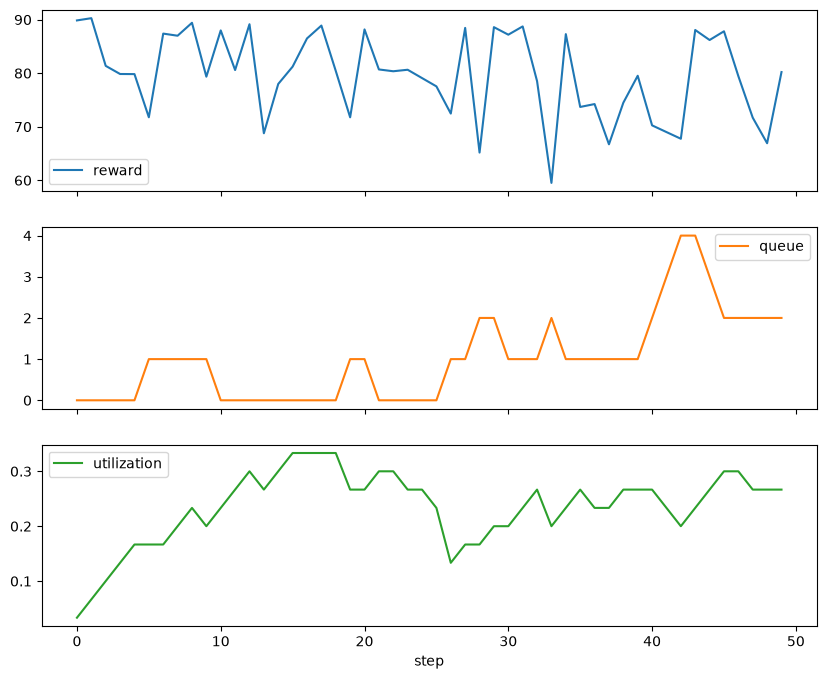

In [3]:
import numpy as np, pandas as pd
env.reset(seed=42); rows=[]
for step in range(50):
 a=int(env.np_random.choice(np.flatnonzero(env.candidate_mask))); _,reward,done,_,info=env.step(a); rows.append({'step':step,'reward':reward,'queue':sum(x.queue_length for x in env.queue_manager.stations.values()),'utilization':sum(x.utilization for x in env.queue_manager.stations.values())/len(env.queue_manager.stations)})
 if done: env.reset()
frame=pd.DataFrame(rows); frame.set_index('step').plot(subplots=True,figsize=(10,8))